In [117]:
## Big Mart Sales Prediction - Regression Model

In [118]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [119]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')


In [120]:
df = pd.read_csv('/Dataset18-Bigmart_sales.csv')
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [121]:
df.shape

(8523, 12)

In [122]:
df.columns

Index(['Item_Identifier', 'Item_Weight', 'Item_Fat_Content', 'Item_Visibility',
       'Item_Type', 'Item_MRP', 'Outlet_Identifier',
       'Outlet_Establishment_Year', 'Outlet_Size', 'Outlet_Location_Type',
       'Outlet_Type', 'Item_Outlet_Sales'],
      dtype='object')

In [123]:
df.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.643456,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.773750,0.026989,93.826500,1987.000000,834.247400
50%,12.600000,0.053931,143.012800,1999.000000,1794.331000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


In [124]:
df.dtypes

,0
Item_Identifier,object
Item_Weight,float64
Item_Fat_Content,object
Item_Visibility,float64
Item_Type,object
Item_MRP,float64
Outlet_Identifier,object
Outlet_Establishment_Year,int64
Outlet_Size,object
Outlet_Location_Type,object


In [125]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [126]:
df.isnull().sum()

,0
Item_Identifier,0
Item_Weight,1463
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,2410
Outlet_Location_Type,0


In [127]:
categorical_columns = df.select_dtypes(include=['object']).columns.tolist()
categorical_columns


['Item_Identifier',
 'Item_Fat_Content',
 'Item_Type',
 'Outlet_Identifier',
 'Outlet_Size',
 'Outlet_Location_Type',
 'Outlet_Type']

In [128]:
numbercial_columns = df.select_dtypes(include=['int64','float64']).columns.tolist()
numbercial_columns

['Item_Weight',
 'Item_Visibility',
 'Item_MRP',
 'Outlet_Establishment_Year',
 'Item_Outlet_Sales']

In [129]:
print(df[categorical_columns].nunique())

Item_Identifier         1559
Item_Fat_Content           5
Item_Type                 16
Outlet_Identifier         10
Outlet_Size                3
Outlet_Location_Type       3
Outlet_Type                4
dtype: int64


In [130]:
for col in categorical_columns:
  print(df[col].value_counts())
  print('_________________________________')

Item_Identifier
FDW13    10
FDG33    10
FDX31     9
FDT07     9
NCY18     9
         ..
FDO33     1
FDK57     1
FDT35     1
FDN52     1
FDE52     1
Name: count, Length: 1559, dtype: int64
_________________________________
Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64
_________________________________
Item_Type
Fruits and Vegetables    1232
Snack Foods              1200
Household                 910
Frozen Foods              856
Dairy                     682
Canned                    649
Baking Goods              648
Health and Hygiene        520
Soft Drinks               445
Meat                      425
Breads                    251
Hard Drinks               214
Others                    169
Starchy Foods             148
Breakfast                 110
Seafood                    64
Name: count, dtype: int64
_________________________________
Outlet_Identifier
OUT027    935
OUT013    932
OUT035    930
OUT049    9

In [131]:
df.duplicated().any()

np.False_

In [132]:
#df[df['Item_Weight'].isnull()]

In [133]:
#item_weight_mean = df.pivot_table(values='Item_Weight',index='Item_Identifier')
#item_weight_mean

In [134]:
item_weight_mean = df.groupby(['Item_Identifier'])['Item_Weight'].mean().reset_index()
item_weight_mean

,Item_Identifier,Item_Weight
0,DRA12,11.600
1,DRA24,19.350
2,DRA59,8.270
3,DRB01,7.390
4,DRB13,6.115
...,...,...
1554,NCZ30,6.590
1555,NCZ41,19.850
1556,NCZ42,10.500
1557,NCZ53,9.600


In [135]:
item_dict = dict(zip(item_weight_mean.Item_Identifier.to_list(),item_weight_mean.Item_Weight.to_list()))
item_dict

{'DRA12': 11.6,
 'DRA24': 19.35,
 'DRA59': 8.27,
 'DRB01': 7.39,
 'DRB13': 6.115,
 'DRB24': 8.785,
 'DRB25': 12.3,
 'DRB48': 16.75,
 'DRC01': 5.92,
 'DRC12': 17.85,
 'DRC13': 8.26,
 'DRC24': 17.85,
 'DRC25': 5.73,
 'DRC27': 13.800000000000002,
 'DRC36': 13.0,
 'DRC49': 8.67,
 'DRD01': 12.1,
 'DRD12': 6.96,
 'DRD13': 15.0,
 'DRD15': 10.6,
 'DRD24': 13.85,
 'DRD25': 6.135000000000001,
 'DRD27': 18.75,
 'DRD37': 9.8,
 'DRD49': 9.895,
 'DRD60': 15.7,
 'DRE01': 10.1,
 'DRE03': 19.6,
 'DRE12': 4.59,
 'DRE13': 6.28,
 'DRE15': 13.35,
 'DRE25': 15.35,
 'DRE27': 11.85,
 'DRE37': 13.5,
 'DRE48': 8.43,
 'DRE49': 20.75,
 'DRE60': 9.395,
 'DRF01': 5.655,
 'DRF03': 19.1,
 'DRF13': 12.1,
 'DRF15': 18.35,
 'DRF23': 4.61,
 'DRF25': 9.0,
 'DRF27': 8.93,
 'DRF36': 16.1,
 'DRF37': 17.25,
 'DRF48': 5.73,
 'DRF49': 7.269999999999999,
 'DRF51': 15.75,
 'DRF60': 10.8,
 'DRG01': 14.800000000000002,
 'DRG03': 14.5,
 'DRG11': 6.385,
 'DRG13': 17.25,
 'DRG15': 6.13,
 'DRG23': 8.88,
 'DRG25': 10.5,
 'DRG27': 8.895,

In [136]:
for index,row in df.iterrows():
  if (pd.isnull(row['Item_Weight'])):
    mean_value = item_dict[row['Item_Identifier']]
    df['Item_Weight'][index] = mean_value

In [137]:
df[df['Item_Weight'].isnull()]

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
927,FDN52,NaN,Regular,0.130933,Frozen Foods,86.9198,OUT027,1985,Medium,Tier 3,Supermarket Type3,1569.9564
1922,FDK57,NaN,Low Fat,0.079904,Snack Foods,120.0440,OUT027,1985,Medium,Tier 3,Supermarket Type3,4434.2280
4187,FDE52,NaN,Regular,0.029742,Dairy,88.9514,OUT027,1985,Medium,Tier 3,Supermarket Type3,3453.5046
5022,FDQ60,NaN,Regular,0.191501,Baking Goods,121.2098,OUT019,1985,Small,Tier 1,Grocery Store,120.5098


In [138]:
item_list = df['Outlet_Type'].unique()
mode_dict = {}

for item in item_list:
    try:
        df1 = df[df['Outlet_Type'] == item]
        df_mode = df1['Outlet_Size'].mode()[0]
        mode_dict[item] = df_mode
    except Exception as e:
        pass

mode_dict

{'Supermarket Type1': 'Small',
 'Supermarket Type2': 'Medium',
 'Grocery Store': 'Small',
 'Supermarket Type3': 'Medium'}

In [139]:
for index,row in df.iterrows():
  try:
    if (pd.isnull(row['Outlet_Size'])):
      mode_value = mode_dict[row['Outlet_Type']]
      df['Outlet_Size'][index] = mode_value
  except Exception as e:
    pass

In [140]:
df[df['Outlet_Size'].isnull()]

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales


In [141]:
df.head(10)

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.300,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.920,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.500,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.200,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,Small,Tier 3,Grocery Store,732.3800
4,NCD19,8.930,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052
5,FDP36,10.395,Regular,0.000000,Baking Goods,51.4008,OUT018,2009,Medium,Tier 3,Supermarket Type2,556.6088
6,FDO10,13.650,Regular,0.012741,Snack Foods,57.6588,OUT013,1987,High,Tier 3,Supermarket Type1,343.5528
7,FDP10,19.000,Low Fat,0.127470,Snack Foods,107.7622,OUT027,1985,Medium,Tier 3,Supermarket Type3,4022.7636
8,FDH17,16.200,Regular,0.016687,Frozen Foods,96.9726,OUT045,2002,Small,Tier 2,Supermarket Type1,1076.5986
9,FDU28,19.200,Regular,0.094450,Frozen Foods,187.8214,OUT017,2007,Small,Tier 2,Supermarket Type1,4710.5350


In [142]:
df.isnull().sum()

,0
Item_Identifier,0
Item_Weight,4
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,0
Outlet_Location_Type,0


In [143]:
df_cleaned = df.dropna()

In [144]:
df_cleaned.isnull().sum()

,0
Item_Identifier,0
Item_Weight,0
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,0
Outlet_Location_Type,0


In [145]:
sum(df_cleaned['Item_Visibility']==0)

526

In [146]:
df_cleaned.loc[:, 'Item_Visibility'].replace([0], [df_cleaned['Item_Visibility'].mean()], inplace=True)

In [147]:
sum(df_cleaned['Item_Visibility']==0)

0

In [148]:
df_cleaned['Item_Fat_Content'].value_counts()

,count
Item_Fat_Content,
Low Fat,5088
Regular,2886
LF,316
reg,117
low fat,112


In [149]:
df_cleaned['Item_Fat_Content'] = df_cleaned['Item_Fat_Content'].replace({'LF':'Low Fat','reg':'Regular','low fat':'Low Fat'})
df_cleaned['Item_Fat_Content'].value_counts()

,count
Item_Fat_Content,
Low Fat,5516
Regular,3003


In [150]:
df_cleaned[['Item_Identifier']]

,Item_Identifier
0,FDA15
1,DRC01
2,FDN15
3,FDX07
4,NCD19
...,...
8518,FDF22
8519,FDS36
8520,NCJ29
8521,FDN46


In [151]:
df_cleaned['New_Item_Type'] = df_cleaned['Item_Identifier'].apply(lambda x: x[:2])
df_cleaned['New_Item_Type']

,New_Item_Type
0,FD
1,DR
2,FD
3,FD
4,NC
...,...
8518,FD
8519,FD
8520,NC
8521,FD


In [152]:
df_cleaned['New_Item_Type'] = df_cleaned['New_Item_Type'].map({'FD':'Food','NC':'Non-Consumable','DR':'Drinks'})
df_cleaned['New_Item_Type'].value_counts()

,count
New_Item_Type,
Food,6121
Non-Consumable,1599
Drinks,799


In [153]:
#### EDA

<Axes: ylabel='Frequency'>

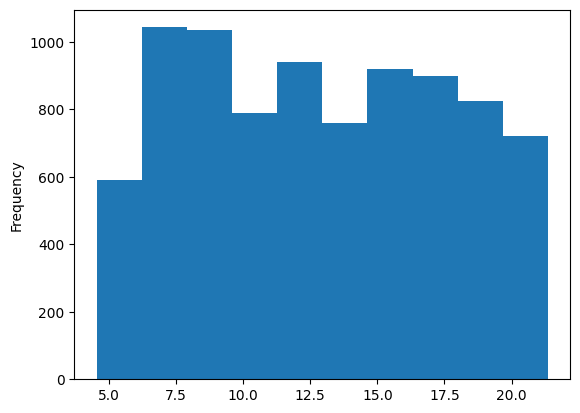

In [154]:
df_cleaned['Item_Weight'].plot(kind = 'hist')

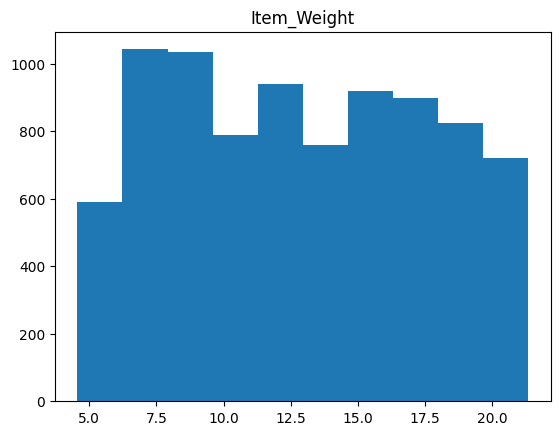

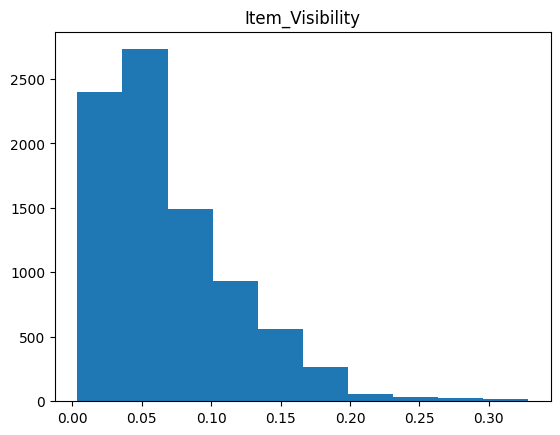

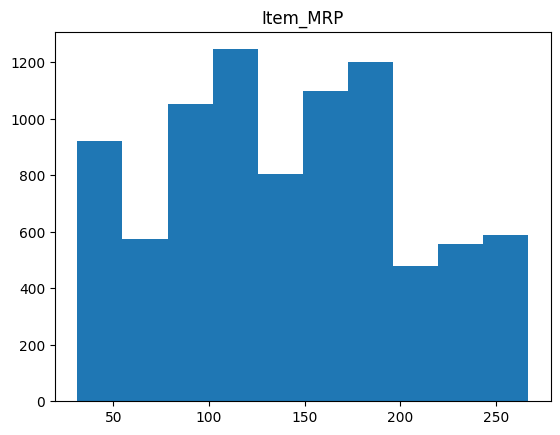

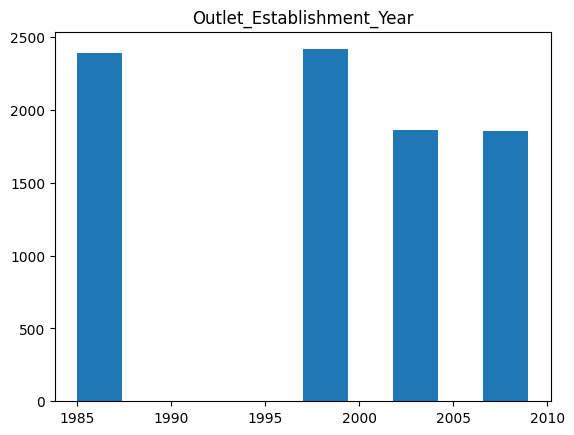

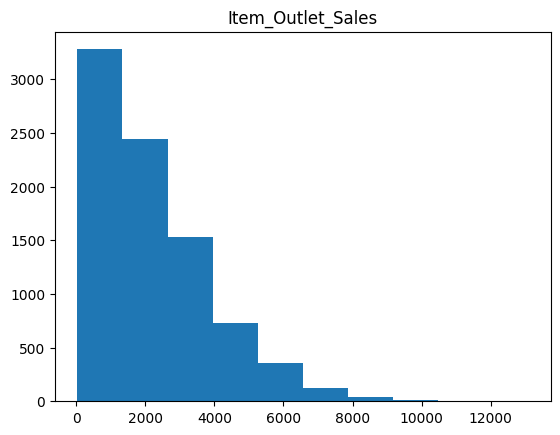

In [155]:
for col in numbercial_columns:
  plt.hist(df_cleaned[col])
  plt.title(col)
  plt.show()


In [156]:
## Categorical Columns

<Axes: xlabel='count', ylabel='Item_Fat_Content'>

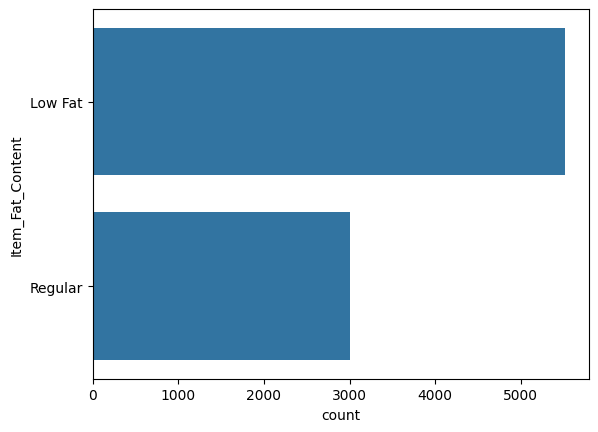

In [157]:
sns.countplot(df_cleaned["Item_Fat_Content"])

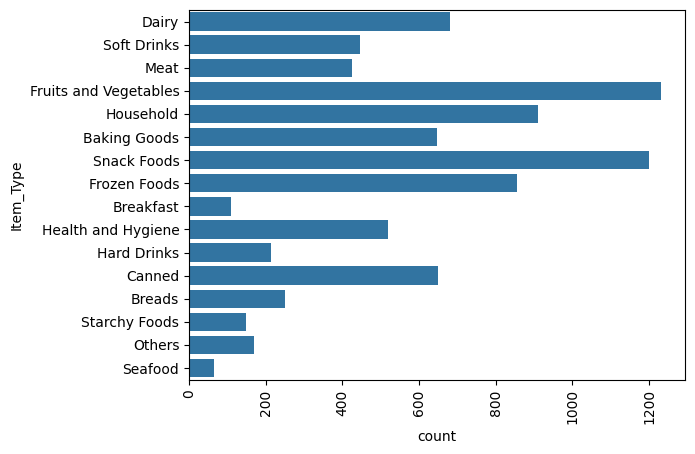

In [158]:
sns.countplot(df_cleaned["Item_Type"])
plt.xticks(rotation = 90)
plt.show()

<Axes: xlabel='count', ylabel='Outlet_Size'>

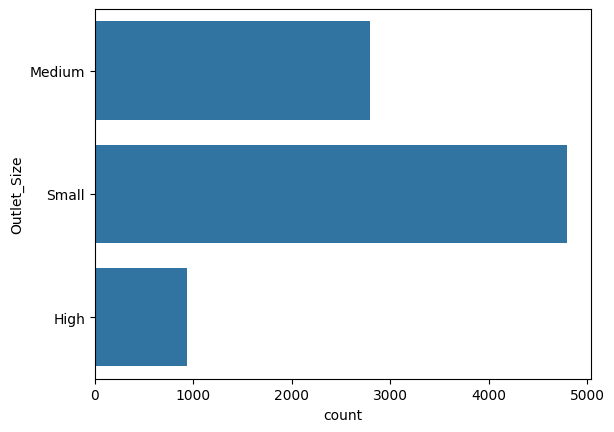

In [159]:
sns.countplot(df_cleaned["Outlet_Size"])

<Axes: xlabel='count', ylabel='Outlet_Location_Type'>

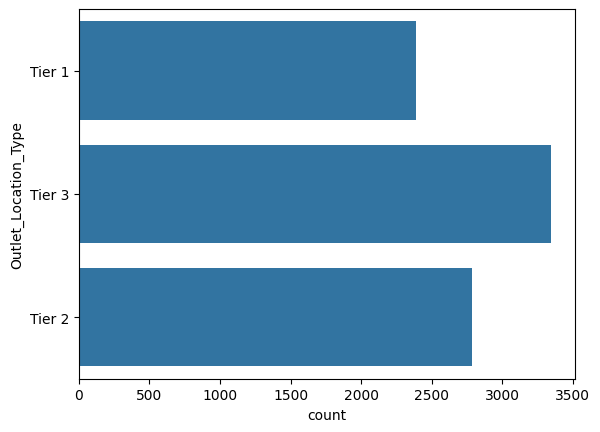

In [160]:
sns.countplot(df_cleaned["Outlet_Location_Type"])

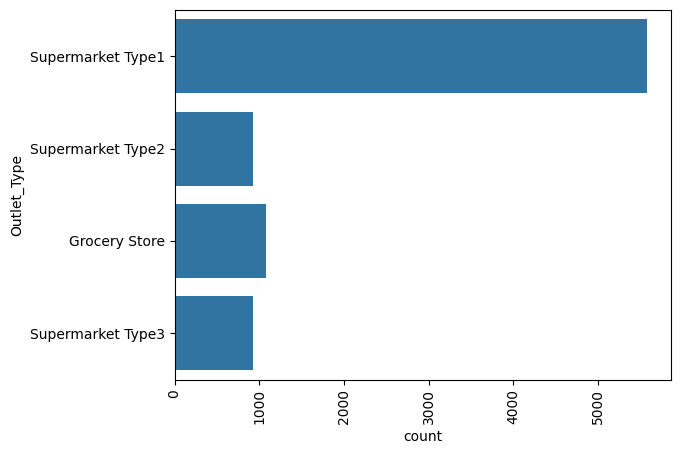

In [161]:
sns.countplot(df_cleaned["Outlet_Type"])
plt.xticks(rotation = 90)
plt.show()

<Axes: ylabel='count'>

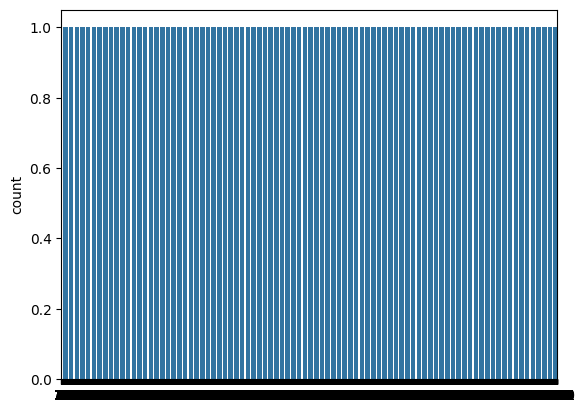

In [162]:
sns.countplot(df_cleaned["Outlet_Establishment_Year"])

In [166]:
corr = df_cleaned[numbercial_columns].corr()
corr

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
Item_Weight,1.000000,-0.017483,0.025975,-0.013426,0.013168
Item_Visibility,-0.017483,1.000000,-0.005115,-0.077878,-0.133788
Item_MRP,0.025975,-0.005115,1.000000,0.004599,0.567803
Outlet_Establishment_Year,-0.013426,-0.077878,0.004599,1.000000,-0.049083
Item_Outlet_Sales,0.013168,-0.133788,0.567803,-0.049083,1.000000


<Axes: >

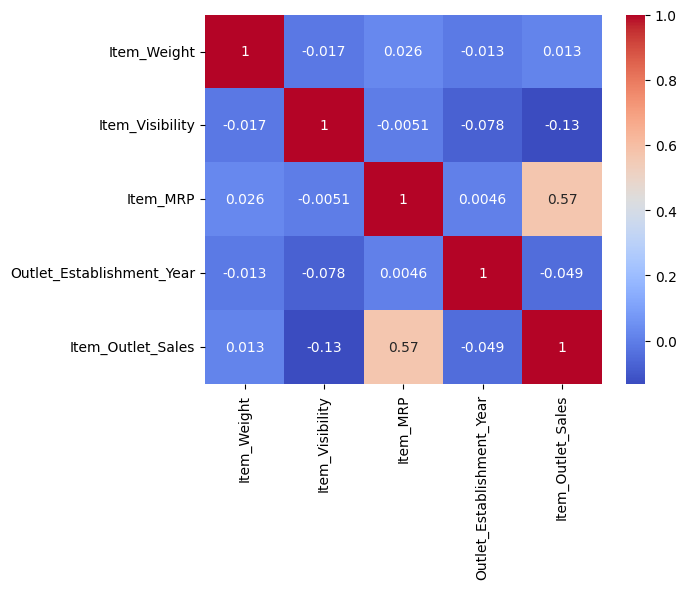

In [167]:
sns.heatmap(corr, annot=True, cmap='coolwarm')

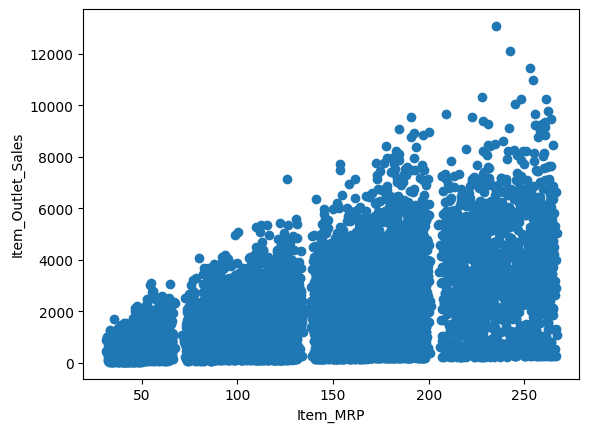

In [168]:
plt.scatter(df_cleaned['Item_MRP'],df_cleaned['Item_Outlet_Sales'])
plt.xlabel('Item_MRP')
plt.ylabel('Item_Outlet_Sales')
plt.show()

In [169]:
df_cleaned = df_cleaned.drop(['Item_Identifier'],axis = 1)

In [170]:
## Label Encoding

In [171]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [175]:
categorical_columns = ['Item_Fat_Content',
 'Item_Type',
 'Outlet_Identifier',
 'Outlet_Size',
 'Outlet_Location_Type',
 'Outlet_Type', 'New_Item_Type']

for col in categorical_columns:
  df_cleaned[col] = le.fit_transform(df_cleaned[col])

In [176]:
df_cleaned.head()

,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,New_Item_Type
0,9.30,0,0.016047,4,249.8092,9,1999,1,0,1,3735.1380,1
1,5.92,1,0.019278,14,48.2692,3,2009,1,2,2,443.4228,0
2,17.50,0,0.016760,10,141.6180,9,1999,1,0,1,2097.2700,1
3,19.20,1,0.066112,6,182.0950,0,1998,2,2,0,732.3800,1
4,8.93,0,0.066112,9,53.8614,1,1987,0,2,1,994.7052,2


In [177]:
###

In [180]:
x = df_cleaned.drop(columns=['Item_Outlet_Sales'], axis = 1)
y = df_cleaned['Item_Outlet_Sales']

In [181]:
x.head()

,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,New_Item_Type
0,9.30,0,0.016047,4,249.8092,9,1999,1,0,1,1
1,5.92,1,0.019278,14,48.2692,3,2009,1,2,2,0
2,17.50,0,0.016760,10,141.6180,9,1999,1,0,1,1
3,19.20,1,0.066112,6,182.0950,0,1998,2,2,0,1
4,8.93,0,0.066112,9,53.8614,1,1987,0,2,1,2


In [182]:
## Feature Scalling

In [183]:
feature_scaled = ['Item_Weight','Item_Visibility','Item_MRP', 'Outlet_Establishment_Year']
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x[feature_scaled] = scaler.fit_transform(x[feature_scaled])

In [184]:
x.head()

,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,New_Item_Type
0,-0.769598,0,-1.111258,4,1.746938,9,0.138865,1,0,1,1
1,-1.497133,1,-1.044950,14,-1.489096,3,1.333806,1,2,2,0
2,0.995427,0,-1.096630,10,0.009762,9,0.138865,1,0,1,1
3,1.361347,1,-0.083776,6,0.659682,0,0.019371,2,2,0,1
4,-0.849240,0,-0.083776,9,-1.399305,1,-1.295064,0,2,1,2


In [185]:
## Train Test Split

In [186]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state= 42)
x_train.shape, x_test.shape

((6815, 11), (1704, 11))

In [188]:
from sklearn.linear_model import LinearRegression


In [189]:
LR = LinearRegression()
LR.fit(x_train,y_train)

LinearRegression()

In [190]:
y_pred = LR.predict(x_test)
y_pred

array([1941.62402977, 1876.23152175,   74.59680573, ..., 1624.25136357,
       1246.5501686 , 2329.26045015])

In [191]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
r2_score(y_test,y_pred)

0.5158031404223624

In [192]:
mean_absolute_error(y_test,y_pred)

887.0193693089863

In [193]:
mean_squared_error(y_test,y_pred)

1439066.043709318

In [194]:
from sklearn.model_selection import cross_val_score
cv_score = cross_val_score(LR,x,y,scoring='r2', cv=5)

cv_score

array([0.51852004, 0.50262056, 0.48278036, 0.50325749, 0.50010735])

In [195]:
cv_score.mean()

np.float64(0.5014571607718897)

In [196]:
# Linear Regression

In [197]:
LR = LinearRegression()
LR.fit(x_train,y_train)
y_pred = LR.predict(x_test)
score = round(r2_score(y_test,y_pred)*100,2)
mse = round(mean_squared_error(y_test,y_pred),2)
print('R2 Score: ',score, '%')
print('MSE: ', mse)

R2 Score:  51.58 %
MSE:  1439066.04


In [198]:
from sklearn.linear_model import Ridge, Lasso
ridge_model = Ridge(alpha = 0.1)
ridge_model.fit(x_train,y_train)
y_pred = ridge_model.predict(x_test)
score = round(r2_score(y_test,y_pred)*100, 2)
mse = round(mean_squared_error(y_test,y_pred),2)
print('R2 Score: ',score, '%')
print('MSE: ', mse)


R2 Score:  51.58 %
MSE:  1439067.83


In [199]:
lasso_model = Lasso(alpha = 0.1)
lasso_model.fit(x_train,y_train)
y_pred = lasso_model.predict(x_test)
score = round(r2_score(y_test,y_pred)*100, 2)
mse = round(mean_squared_error(y_test,y_pred),2)
print('R2 Score: ',score, '%')
print('MSE: ', mse)

R2 Score:  51.58 %
MSE:  1439070.93


In [200]:
from sklearn.tree import DecisionTreeRegressor
dt_model = DecisionTreeRegressor()
dt_model.fit(x_train,y_train)
y_pred = dt_model.predict(x_test)
score = round(r2_score(y_test,y_pred)*100, 2)
mse = round(mean_squared_error(y_test,y_pred),2)
print('R2 Score: ',score, '%')
print('MSE: ', mse)


R2 Score:  18.86 %
MSE:  2411636.23


In [201]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor()
rf_model.fit(x_train,y_train)
y_pred = rf_model.predict(x_test)
score = round(r2_score(y_test,y_pred)*100, 2)
mse = round(mean_squared_error(y_test,y_pred),2)
print('R2 Score: ',score, '%')
print('MSE: ', mse)


R2 Score:  55.78 %
MSE:  1314169.89


In [202]:
from sklearn.ensemble import GradientBoostingRegressor
gb_model = GradientBoostingRegressor()
gb_model.fit(x_train,y_train)
y_pred = gb_model.predict(x_test)
score = round(r2_score(y_test,y_pred)*100,2)
mse = round(mean_squared_error(y_test,y_pred),2)
print('R2 Score: ',score, '%')
print('MSE: ', mse)

R2 Score:  60.12 %
MSE:  1185208.14


In [203]:
from sklearn.ensemble import ExtraTreesRegressor
et_model = ExtraTreesRegressor()
et_model.fit(x_train,y_train)
y_pred = et_model.predict(x_test)
score = round(r2_score(y_test,y_pred)*100,2)
mse = round(mean_squared_error(y_test,y_pred),2)
print('R2 Score: ',score, '%')
print('MSE: ', mse)

R2 Score:  52.57 %
MSE:  1409762.15


In [204]:
from sklearn.neighbors import KNeighborsRegressor
knn_model = KNeighborsRegressor()
knn_model.fit(x_train,y_train)
y_pred = knn_model.predict(x_test)
score = round(r2_score(y_test,y_pred)*100,2)
mse = round(mean_squared_error(y_test,y_pred),2)
print('R2 Score: ',score, '%')
print('MSE: ', mse)


R2 Score:  48.75 %
MSE:  1523095.58


In [205]:
from sklearn.svm import SVR
svr_model = SVR()
svr_model.fit(x_train,y_train)
y_pred = svr_model.predict(x_test)
score = round(r2_score(y_test,y_pred)*100,2)
mse = round(mean_squared_error(y_test,y_pred),2)
print('R2 Score: ',score, '%')
print('MSE: ', mse)


R2 Score:  -0.46 %
MSE:  2985695.59


In [206]:
from sklearn.model_selection import cross_val_score
cv_score = cross_val_score(rf_model,x,y,scoring='r2', cv=5)

cv_score

array([0.57232669, 0.53095579, 0.52536292, 0.56599528, 0.57080875])

In [209]:
print(f"Accuracy of the Model = {round(cv_score.mean()*100,2)} %")

Accuracy of the Model = 55.31 %


<Axes: title={'center': 'Feature Importance'}>

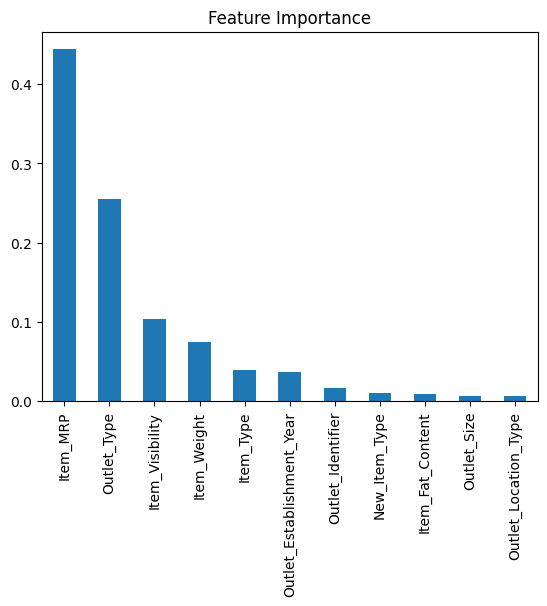

In [210]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor()
rf_model.fit(x,y)
coef = pd.Series(rf_model.feature_importances_, index = x.columns).sort_values(ascending = False)
coef.plot(kind='bar', title='Feature Importance')

In [211]:
## MODEL PREDICTIVE SYSTEM

In [214]:
df_cleaned.columns

Index(['Item_Weight', 'Item_Fat_Content', 'Item_Visibility', 'Item_Type',
       'Item_MRP', 'Outlet_Identifier', 'Outlet_Establishment_Year',
       'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type',
       'Item_Outlet_Sales', 'New_Item_Type'],
      dtype='object')

In [217]:
data = (9.4, 0, 0.63, 4, 253, 9, 1997, 1, 0, 1, 1)
data_array = np.array(data)
data_reshaped = data_array.reshape(1,-1)
data_reshaped

array([[9.400e+00, 0.000e+00, 6.300e-01, 4.000e+00, 2.530e+02, 9.000e+00,
        1.997e+03, 1.000e+00, 0.000e+00, 1.000e+00, 1.000e+00]])

In [218]:
predict = rf_model.predict(data_reshaped)
print("Sales Prediction by Model = ", predict[0])

Sales Prediction by Model =  4924.003795999999
